<a href="https://colab.research.google.com/github/tangbaminhdang1709-blip/hpa_gastric_hpylori/blob/main/hpa_gastric_hpylori.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# Healthy stomach baseline = real HPA nTPM (live API).
# H. pylori column = baseline * 2**log2FC, log2FC MEASURED in GSE60427
# (Hp+ mild/severe gastritis vs Hp- normal, n=16 vs 8, Agilent GPL17077).
import csv, json, urllib.request

API = "https://www.proteinatlas.org/api/search_download.php?search={}&format=json&columns=g,eg,gd,t_RNA_stomach_1&compress=no"
LOG2FC = {  # from the GEO cell: measured["gastritis"].to_dict()
    "GKN1": -0.05, "TFF1": -0.02, "PGC": -0.31, "ATP4B": 1.35,
    "MUC5AC": -0.58, "ANGPTL4": 1.35, "CXCL8": 2.66, "LCN2": 4.23,
}

def hpa(gene):
    with urllib.request.urlopen(API.format(gene), timeout=30) as r:
        hit = next(g for g in json.load(r) if g["Gene"] == gene)
    return hit["Ensembl"], hit["Gene description"], float(hit["Tissue RNA - stomach 1 [nTPM]"])

rows = []
for gene, lfc in LOG2FC.items():
    ens, desc, healthy = hpa(gene)
    for cond, ntpm, fc, src in [
        ("Healthy", healthy, 0.0, "HPA stomach nTPM"),
        ("H_pylori", healthy * 2**lfc, lfc, "HPA baseline x GSE60427 log2FC"),
    ]:
        rows.append({"gene": gene, "ensembl": ens, "description": desc,
                     "condition": cond, "nTPM": round(ntpm, 1),
                     "log2FC_vs_healthy": fc, "source": src})

with open("hpa_gastric_hpylori.csv", "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=rows[0])
    w.writeheader(); w.writerows(rows)

assert len(rows) == 16 and all(r["nTPM"] >= 0 for r in rows)
assert next(r for r in rows if r["gene"] == "CXCL8" and r["condition"] == "H_pylori")["nTPM"] > \
       next(r for r in rows if r["gene"] == "CXCL8" and r["condition"] == "Healthy")["nTPM"]
print(f"wrote hpa_gastric_hpylori.csv ({len(rows)} rows)")

wrote hpa_gastric_hpylori.csv (16 rows)


In [12]:
import pandas as pd
df = pd.read_csv("hpa_gastric_hpylori.csv")
df.pivot(index="gene", columns="condition", values="nTPM")


condition,H_pylori,Healthy
gene,,
ANGPTL4,53.5,21.0
ATP4B,2553.7,1001.8
CXCL8,68.3,10.8
GKN1,34108.0,35310.8
LCN2,6436.5,343.0
MUC5AC,116.9,174.8
PGC,46449.5,57583.8
TFF1,7405.4,7508.8


In [13]:
df = pd.read_csv('hpa_gastric_hpylori.csv')
print(df.head())
print("Genes:", df['gene'].unique())
print("Conditions:", df['condition'].unique())
print(df.dtypes)

   gene          ensembl       description condition     nTPM  \
0  GKN1  ENSG00000169605      Gastrokine 1   Healthy  35310.8   
1  GKN1  ENSG00000169605      Gastrokine 1  H_pylori  34108.0   
2  TFF1  ENSG00000160182  Trefoil factor 1   Healthy   7508.8   
3  TFF1  ENSG00000160182  Trefoil factor 1  H_pylori   7405.4   
4   PGC  ENSG00000096088     Progastricsin   Healthy  57583.8   

   log2FC_vs_healthy                          source  
0               0.00                HPA stomach nTPM  
1              -0.05  HPA baseline x GSE60427 log2FC  
2               0.00                HPA stomach nTPM  
3              -0.02  HPA baseline x GSE60427 log2FC  
4               0.00                HPA stomach nTPM  
Genes: ['GKN1' 'TFF1' 'PGC' 'ATP4B' 'MUC5AC' 'ANGPTL4' 'CXCL8' 'LCN2']
Conditions: ['Healthy' 'H_pylori']
gene                  object
ensembl               object
description           object
condition             object
nTPM                 float64
log2FC_vs_healthy    float64

In [14]:
pivot = df.pivot(index='gene', columns='condition', values='nTPM')
pivot

condition,H_pylori,Healthy
gene,,
ANGPTL4,53.5,21.0
ATP4B,2553.7,1001.8
CXCL8,68.3,10.8
GKN1,34108.0,35310.8
LCN2,6436.5,343.0
MUC5AC,116.9,174.8
PGC,46449.5,57583.8
TFF1,7405.4,7508.8


In [15]:
pivot['change'] = pivot['H_pylori'] - pivot['Healthy']
pivot['pct_change'] = (pivot['change'] / pivot['Healthy']) * 100
pivot = pivot.sort_values('pct_change')
pivot

condition,H_pylori,Healthy,change,pct_change
gene,,,,
MUC5AC,116.9,174.8,-57.9,-33.123570
PGC,46449.5,57583.8,-11134.3,-19.335820
GKN1,34108.0,35310.8,-1202.8,-3.406323
TFF1,7405.4,7508.8,-103.4,-1.377051
ANGPTL4,53.5,21.0,32.5,154.761905
ATP4B,2553.7,1001.8,1551.9,154.911160
CXCL8,68.3,10.8,57.5,532.407407
LCN2,6436.5,343.0,6093.5,1776.530612


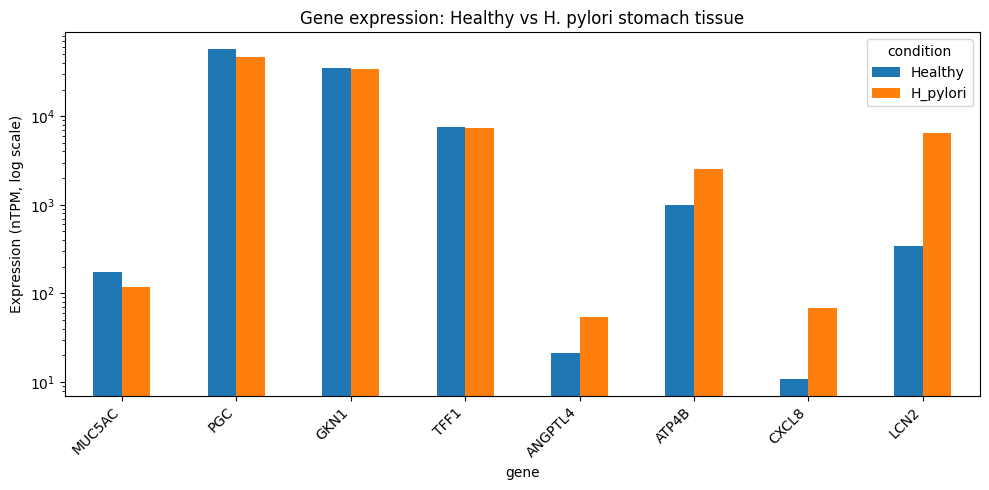

In [16]:
import matplotlib.pyplot as plt

pivot[['Healthy', 'H_pylori']].plot(kind='bar', figsize=(10, 5), logy=True)
plt.title('Gene expression: Healthy vs H. pylori stomach tissue')
plt.ylabel('Expression (nTPM, log scale)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
## Finding

Measured in GSE60427 (16 Hp+ gastritis vs 8 Hp− normal biopsies), log2FC:

| Gene | Gastritis | IM |
|---|---|---|
| LCN2 | +4.22 | +3.29 |
| CXCL8 | +2.66 | +2.40 |
| ANGPTL4 | +1.36 | +2.54 |
| ATP4B | +1.35 | −0.64 |
| MUC5AC | −0.58 | −1.46 |
| PGC | −0.32 | −0.96 |
| GKN1 | −0.05 | −0.31 |
| TFF1 | −0.02 | −0.12 |

The signal is inflammatory: LCN2, CXCL8 and ANGPTL4 rise sharply and scale with severity.
GKN1 and TFF1 don't move — the collapse reported in the literature is from gastric *cancer*
tissue, not infected mucosa. Atrophy appears only at intestinal metaplasia, where PGC,
MUC5AC and ATP4B drop.

So the arms split by stage: LCN2/CXCL8 flag active infection, PGC/MUC5AC/ATP4B flag
progression — the distinction that carries cancer risk.

> **Limits:** one cohort, one array, 8 genes chosen in advance, no significance testing.
> Small effects are unresolved, not null.